1 часть
 1. Скачать один из наборов данных
 2. Загрузить данные в датафрейм
 3. Вывести статистическую информацию о наборе данных
 4. Вывести названия столбцов и строк
 5. Заменить категориальные данные количественными
 6. Визуализировать данные с помощью Matplotlib и Seaborn
 7. Должно быть не менее 2х визуализаций на каждый признак. Выберите самые красивые визуализации!
 8. Должно быть не менее 3х групповых визуализаций

1. Скачала датасет по оценке качества обучения по математике в ВУЗах: https://archive.ics.uci.edu/dataset/1031/dataset+for+assessing+mathematics+learning+in+higher+education

Использую те же библиотеки что и в лекции

In [1]:
import pandas as pd # для анализа
import numpy as np # для анализа
import matplotlib.pyplot as plt # для графиков
import seaborn as sns # для графиков

sns.set(style="whitegrid", palette="muted")

2. Теперь грузимм табличку с данными в блокнот

In [5]:
df = pd.read_csv("MathEdataset.csv", sep=";", encoding="cp1251")

Проверяем результат, смотрим первые последние случайные строки

In [6]:
df.head()
df.tail()
df.sample(5, random_state=42)

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
7135,751,Lithuania,568,0,Basic,Analytic Geometry,Analytic Geometry,"Cartesian equations of a plane,Cartesian equat..."
9432,85,Lithuania,1144,1,Basic,Set Theory,Set Theory,Subset
2750,37,Portugal,337,1,Basic,Complex Numbers,Complex Numbers,"Algebraic form,Principal argument,De Moivre fo..."
8973,80,Lithuania,955,0,Basic,Optimization,Linear Optimization,Linear programming
5756,966,Portugal,444,0,Basic,Linear Algebra,Linear Transformations,"Range,Kernel"


#### 3. Статистическая информация о наборе данных

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9546 entries, 0 to 9545
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Student ID       9546 non-null   int64 
 1   Student Country  9546 non-null   object
 2   Question ID      9546 non-null   int64 
 3   Type of Answer   9546 non-null   int64 
 4   Question Level   9546 non-null   object
 5   Topic            9546 non-null   object
 6   Subtopic         9546 non-null   object
 7   Keywords         9546 non-null   object
dtypes: int64(3), object(5)
memory usage: 596.8+ KB


info() показывает количество строк, типы столбцов и наличие пропусков. Что мы тут видим: 9546 строк с индексами от 0 до 9545; всего 8 столбцов

Дальше идёт таблица с описанием столбцов:
(#) - порядковый номер столбца.
Column - имя столбца
Non-Null Count - сколько ненулевых (ненулевых/не NaN) значений; у нас во всех 9546, значит пропусков нет
Dtype - тип данных столбца:
int64 - целые числа (например, Student ID, Question ID, Type of Answer).
object - обычно строки/тексты (Student Country, Question Level, Topic, Subtopic, Keywords).
Строка dtypes: int64(3), object(5) означает, что всего 3 числовых столбца типа int64 и 5 текстовых столбцов типа object.

memory usage: 596.8+ KB - примерный объём оперативной памяти, который занимает этот DataFrame (около 600 КБ).

In [8]:
df.describe()


,Student ID,Question ID,Type of Answer
count,9546.000000,9546.000000,9546.000000
mean,775.402263,478.912319,0.468259
std,460.590559,249.244061,0.499018
min,26.000000,77.000000,0.000000
25%,380.000000,323.000000,0.000000
50%,885.000000,428.000000,0.000000
75%,1219.000000,571.000000,1.000000
max,1565.000000,1549.000000,1.000000


describe() даёт минимум, максимум, среднее, квартили и стандартное отклонение для числовых признаков (описательная статистика числовых полей)

count - сколько ненулевых значений в каждом столбце; у всех трёх по 9546, пропусков нет
mean - среднее значение: Student ID в среднем около 775; Question ID около 479; Type of Answer около 0.47 (то есть доля единиц примерно 47%)
std - стандартное отклонение (разброс значений вокруг среднего). Чем больше std, тем сильнее разброс.
min и max - минимальное и максимальное значения в столбце (границы диапазона)
25%, 50%, 75% - квартили: у 25% записей значение не превышает указанное в строке 25%; 50% - медиана (половина значений меньше или равна этому числу); 75% - у 75% записей значение не больше этого числа

In [9]:
df.describe(include=["object"])


,Student Country,Question Level,Topic,Subtopic,Keywords
count,9546,9546,9546,9546,9546
unique,8,2,14,24,365
top,Portugal,Basic,Linear Algebra,Vector Spaces,"Linear application,Linearity"
freq,5495,7844,5726,2749,443


Статистика по категориальным признакам. Так мы видим количество уникальных стран, уровней вопросов, тем, подтем и наборов ключевых слов, а также самые частые значения и их частоты. 

всего 8 стран, больше всего студентов из Португалии (5495 записей)
Question Level: всего 2 уровня, доминирует Basic (7844 записей)
Topic: 14 разных тем, чаще всего встречается Linear Algebra (5726 записей)
Subtopic: 24 разных подтем, чаще всего Vector Spaces (2749 записей)
Keywords: очень разнообразные - 365 уникальных комбинаций, самая частая встречается 443 раза и связана с линейными отображениями и линейностью

#### 4. Названия столбцов и строк

In [10]:
df.columns # Названия столбцов

Index(['Student ID', 'Student Country', 'Question ID', 'Type of Answer',
       'Question Level', 'Topic', 'Subtopic', 'Keywords'],
      dtype='object')

Student ID - идентификатор студента;

Student Country - страна студентa;

Question ID - идентификатор вопроса;

Type of Answer - тип ответа (скорее всего 0/1 или категории);

Question Level - уровень вопроса (например, Basic / Advanced);

Topic - тема вопроса (например, Linear Algebra);

Subtopic - подтема (например, Vector Spaces);

Keywords - ключевые слова, описывающие вопрос.

In [11]:
df.index # Индексы строк

RangeIndex(start=0, stop=9546, step=1)

используется стандартный целочисленный индекс по умолчанию: от 0 до 9545 с шагом 1. Это значит, что каждая строка просто пронумерована подряд без пропусков и специальных меток

Анализ пропусков и дубликатов

In [ ]:
df.isnull().sum() # считает количество пропусков по каждому столбцу
df.duplicated().sum()

np.int64(2083)

df.duplicated().sum() вернуло np.int64(2083) это значит, что в датасете 2083 полностью дублирующихся строк (совпадают все столбцы)

#### 5. Замена категориальных данных количественными

У нас есть следующие категориальные столбцы:Student Country,Question Level,Topic,Subtopic

In [16]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols_simple = ["Student Country", "Question Level", "Topic", "Subtopic"]

enc = OrdinalEncoder()
df[cat_cols_simple] = enc.fit_transform(df[cat_cols_simple])
df[cat_cols_simple].head()



,Student Country,Question Level,Topic,Subtopic
0,0.0,1.0,13.0,22.0
1,3.0,1.0,13.0,22.0
2,3.0,1.0,13.0,22.0
3,1.0,1.0,13.0,22.0
4,3.0,1.0,13.0,22.0


OrdinalEncoder превращает текстовые категории в целые числа, чтобы их можно было подавать в большинство алгоритмов машинного обучения.
Здесь мы закодировали категориальные столбцы, заменены на целые коды от 0 до n(категорий) - 1 в каждом столбце

#### 6. Визуализация данных

Распределение целевой переменной Type of Answer

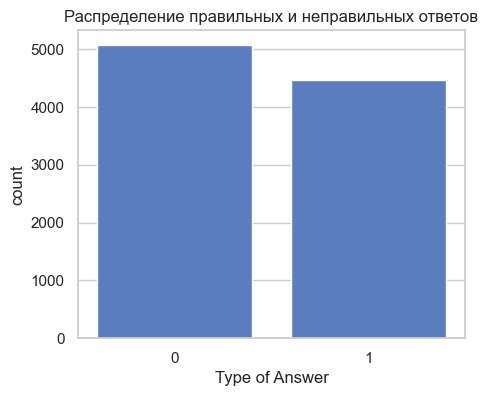

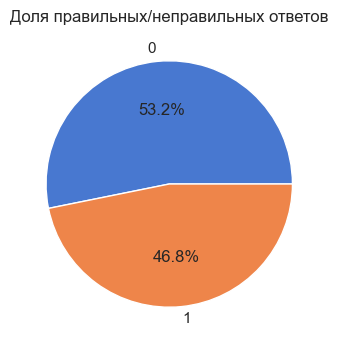

In [18]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Type of Answer", data=df)
plt.title("Распределение правильных и неправильных ответов")
plt.show()

plt.figure(figsize=(5, 4))
df["Type of Answer"].value_counts(normalize=True).plot(kind="pie", autopct="%.1f%%")
plt.title("Доля правильных/неправильных ответов")
plt.ylabel("")
plt.show()

Получается, что большинство 53% ответов неправильные (49 правильные), хотя разница небольшая

Признак Student Country

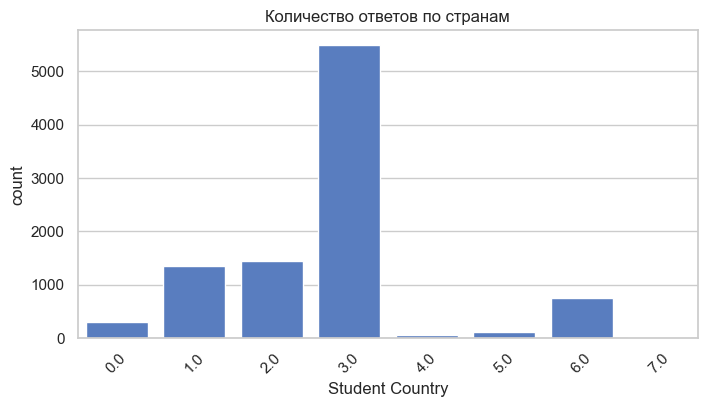

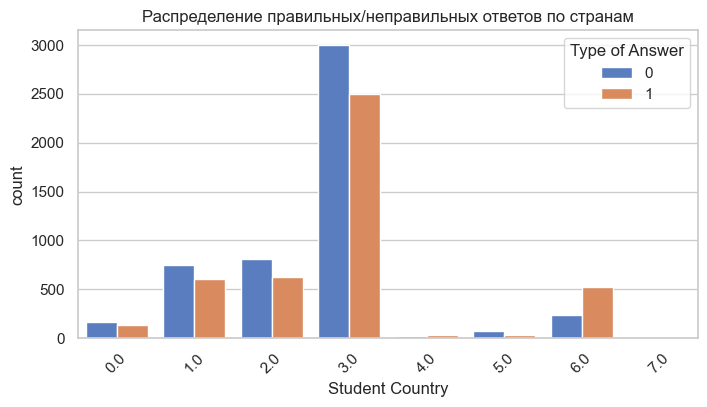

In [19]:
plt.figure(figsize=(8, 4))
sns.countplot(x="Student Country", data=df)
plt.title("Количество ответов по странам")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x="Student Country", hue="Type of Answer", data=df)
plt.title("Распределение правильных/неправильных ответов по странам")
plt.xticks(rotation=45)
plt.show()


тк мы до этого закодировали строки в датасете, то на графике эту же кодировку и видим. Помнится, что наибольшее количество ответов было у Португалии => 3 - это Португалия
Первая диаграмма показывает, какие страны доминируют в выборке
Вторая - (групповая визуализация) даёт гипотезы, различается ли успешность студентов между странами

Признак Question Level

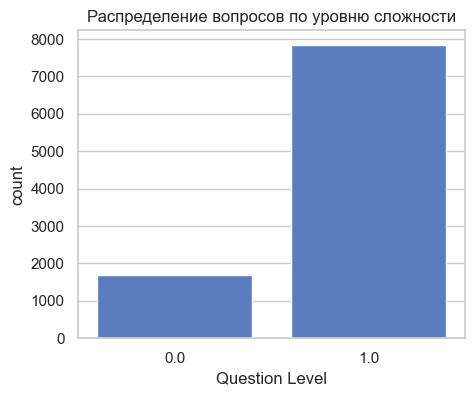

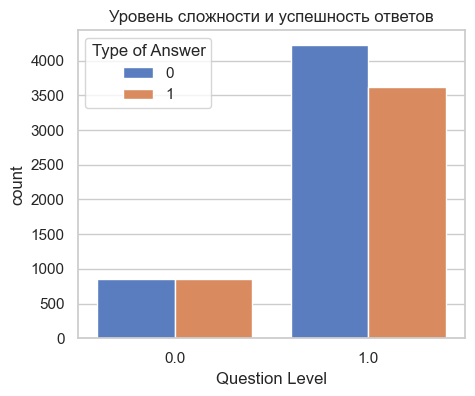

In [20]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Question Level", data=df)
plt.title("Распределение вопросов по уровню сложности")
plt.show()

plt.figure(figsize=(5, 4))
sns.countplot(x="Question Level", hue="Type of Answer", data=df)
plt.title("Уровень сложности и успешность ответов")
plt.show()

Мы видим, какая доля вопросов базового и продвинутого уровня и как это связано с вероятностью правильного ответа. сложные вопросы должны, как правило, давать больше неправильных ответов
на более сложном уровне 1.0 количество и правильных, и неправильных ответов существенно выше, чем на уровне 0.0, то есть основная часть активности приходится на более сложные вопросы

Признаки Topic и Subtopic

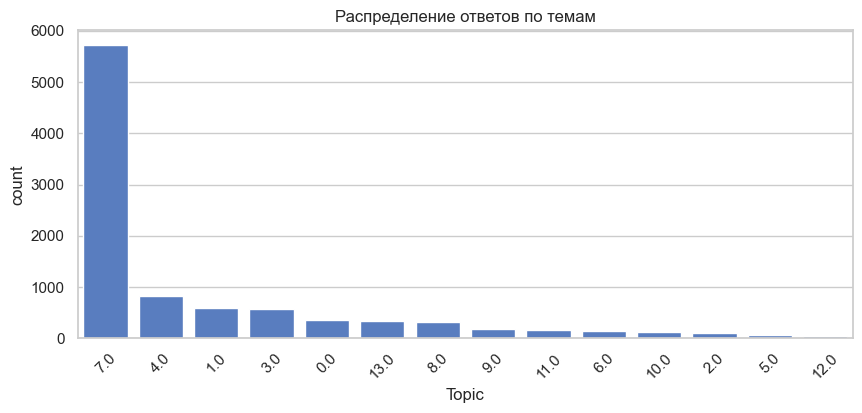

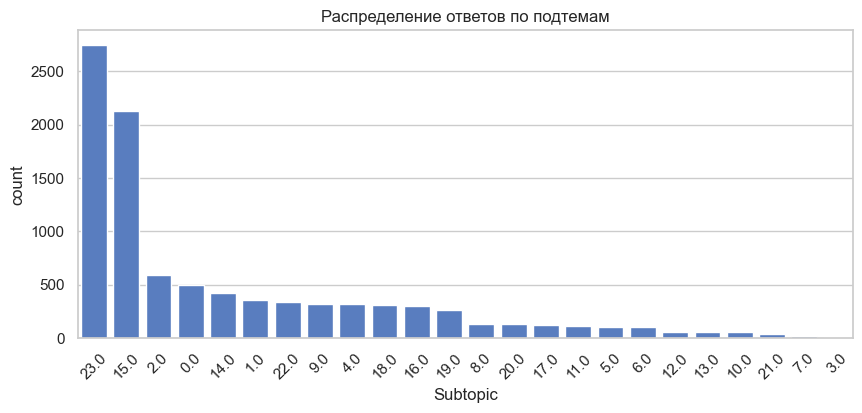

In [21]:
plt.figure(figsize=(10, 4))
sns.countplot(x="Topic", data=df, order=df["Topic"].value_counts().index)
plt.title("Распределение ответов по темам")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(x="Subtopic", data=df, order=df["Subtopic"].value_counts().index)
plt.title("Распределение ответов по подтемам")
plt.xticks(rotation=45)
plt.show()

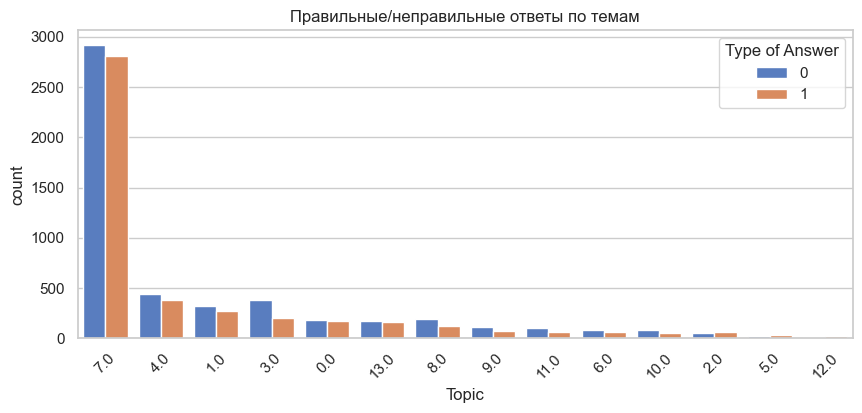

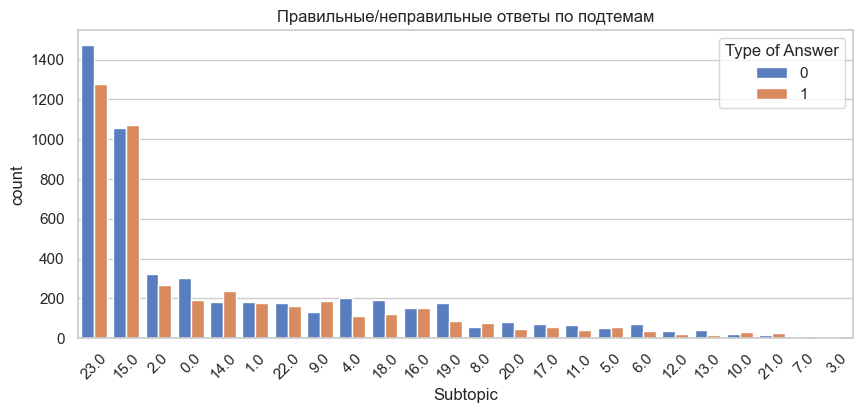

In [22]:
plt.figure(figsize=(10, 4))
sns.countplot(x="Topic", hue="Type of Answer", data=df,
              order=df["Topic"].value_counts().index)
plt.title("Правильные/неправильные ответы по темам")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(x="Subtopic", hue="Type of Answer", data=df,
              order=df["Subtopic"].value_counts().index)
plt.title("Правильные/неправильные ответы по подтемам")
plt.xticks(rotation=45)
plt.show()


Так мы видим, какие темы и подтемы встречаются чаще, и в каких областях студенты чаще ошибаются

Question ID и плотность ответов по вопросам

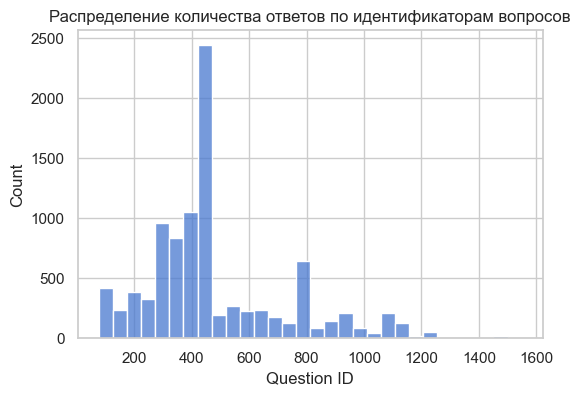

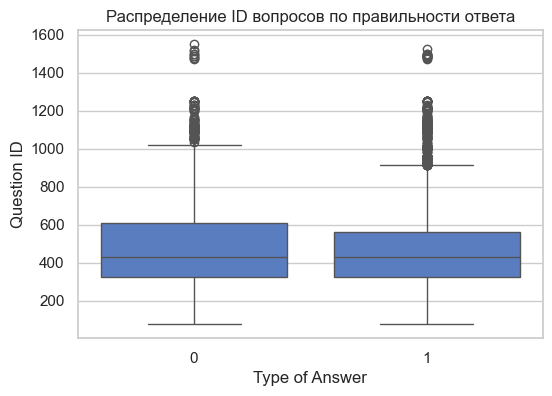

In [23]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Question ID"], bins=30, kde=False)
plt.title("Распределение количества ответов по идентификаторам вопросов")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x="Type of Answer", y="Question ID", data=df)
plt.title("Распределение ID вопросов по правильности ответа")
plt.show()


Гистограмма показывает, насколько равномерно студенты отвечали на различные вопросы: есть ли вопросы, на которые ответило заметно больше людей
Боксплот даёт гипотезу нет ли групп вопросов (по ID), которые чаще связаны с неправильными ответами (например, большой диапазон ID, где преобладают ошибки)

Признак Keywords_Count

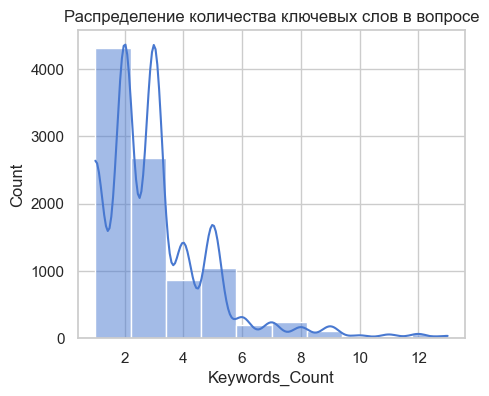

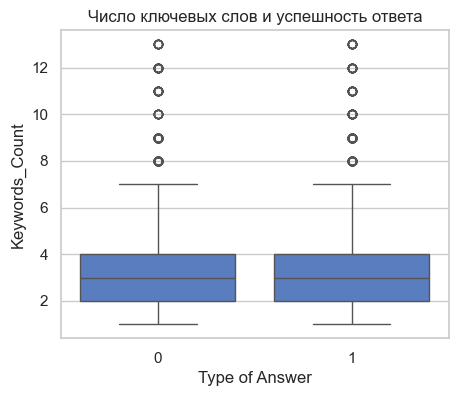

In [24]:
plt.figure(figsize=(5, 4))
sns.histplot(df["Keywords_Count"], bins=10, kde=True)
plt.title("Распределение количества ключевых слов в вопросе")
plt.show()

plt.figure(figsize=(5, 4))
sns.boxplot(x="Type of Answer", y="Keywords_Count", data=df)
plt.title("Число ключевых слов и успешность ответа")
plt.show()


#### Еще две-три групповые визуализации

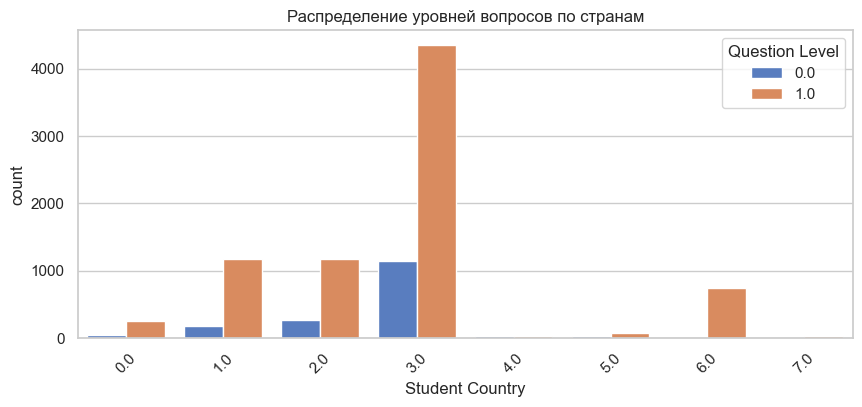

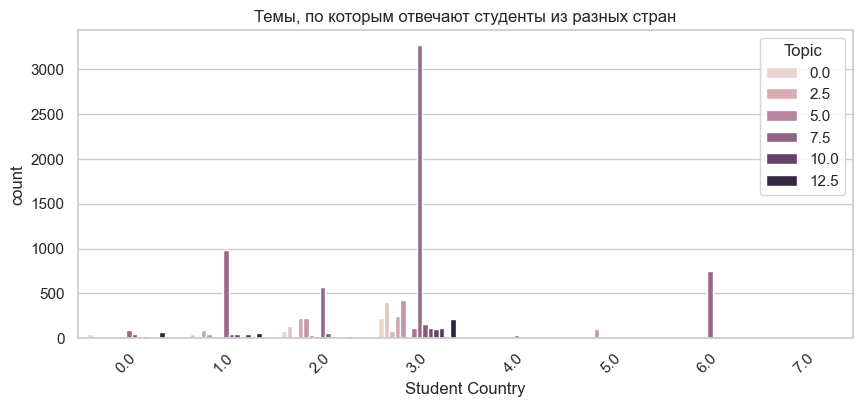

<Figure size 1000x400 with 0 Axes>

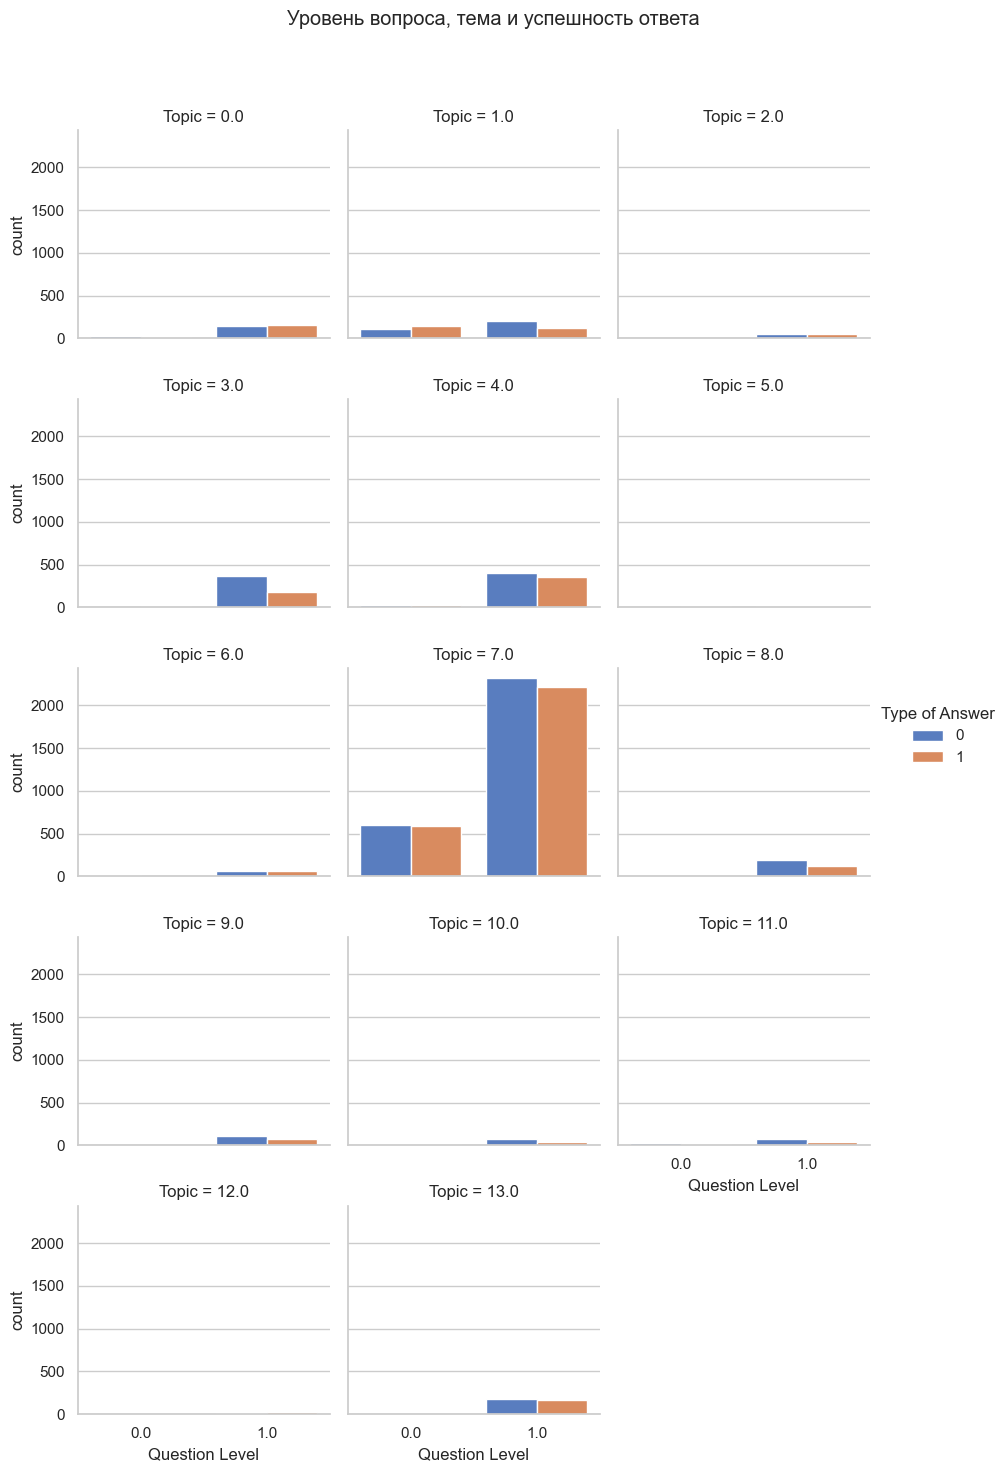

In [25]:
# Страна х Уровень вопроса
plt.figure(figsize=(10, 4))
sns.countplot(x="Student Country", hue="Question Level", data=df)
plt.title("Распределение уровней вопросов по странам")
plt.xticks(rotation=45)
plt.show()

# Страна х Тема
plt.figure(figsize=(10, 4))
sns.countplot(x="Student Country", hue="Topic", data=df)
plt.title("Темы, по которым отвечают студенты из разных стран")
plt.xticks(rotation=45)
plt.show()

# Уровень вопроса х Тема с учётом правильности
plt.figure(figsize=(10, 4))
sns.catplot(
    x="Question Level", hue="Type of Answer",
    col="Topic", data=df, kind="count",
    col_wrap=3, height=3
)
plt.subplots_adjust(top=0.9)
plt.suptitle("Уровень вопроса, тема и успешность ответа")
plt.show()
